# Phase 5 – Analyse de séries temporelles


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Instagram data.csv", encoding="latin1")

df["engagement"] = (df["Likes"] + df["Comments"] + df["Shares"]) / df["Impressions"]

df["date_simulee"] = pd.date_range(start="2023-01-01", periods=len(df), freq="D")

# L’évolution du taux d’engagement

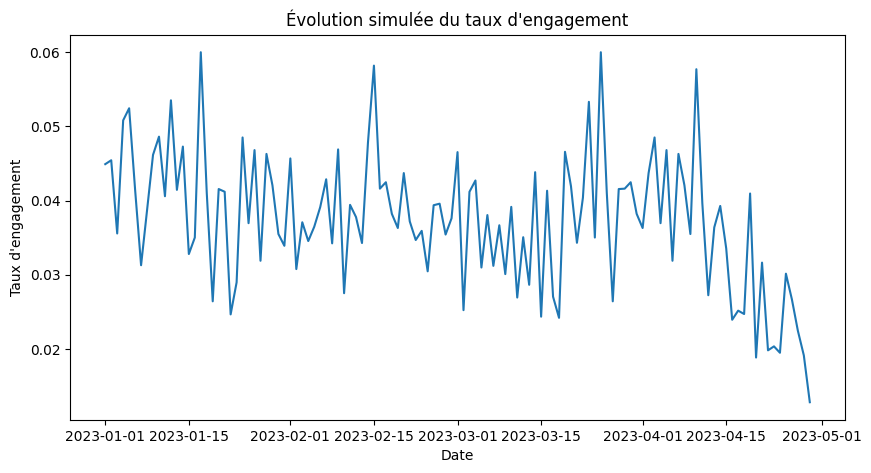

In [2]:
plt.figure(figsize=(10,5))

plt.plot(df["date_simulee"], df["engagement"])

plt.title("Évolution simulée du taux d'engagement")
plt.xlabel("Date")
plt.ylabel("Taux d'engagement")

plt.show()

# engagement par jour de la semaine

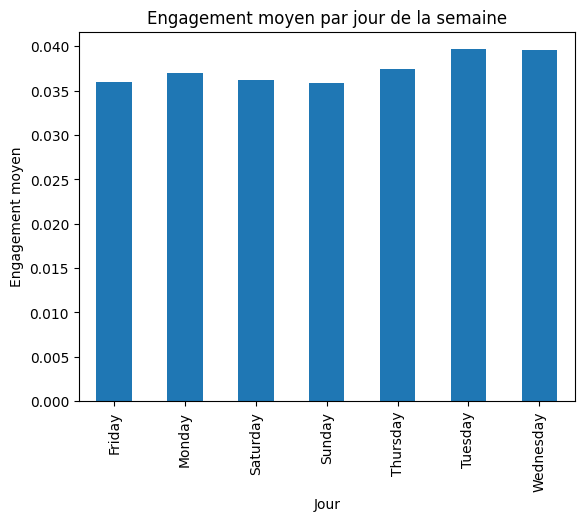

In [3]:
df["jour_semaine"] = df["date_simulee"].dt.day_name()

engagement_jour = df.groupby("jour_semaine")["engagement"].mean()

engagement_jour.plot(kind="bar")

plt.title("Engagement moyen par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Engagement moyen")

plt.show()

### La tendance du taux d’engagement



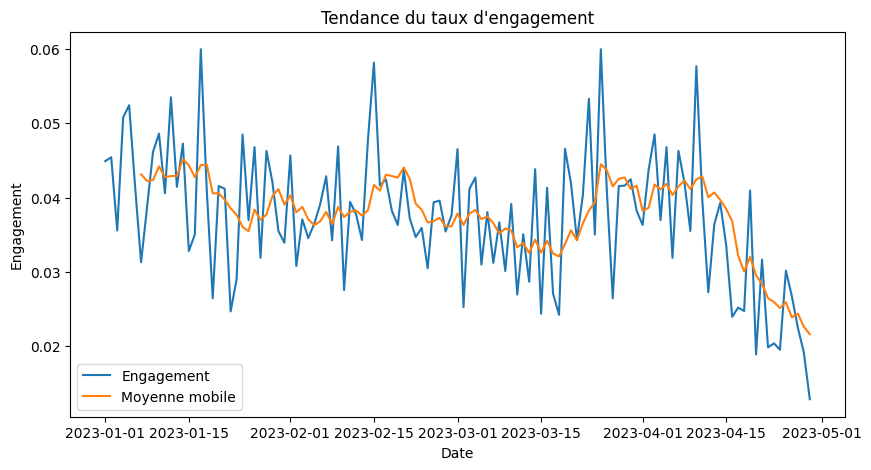

In [4]:
df["moyenne_mobile"] = df["engagement"].rolling(window=7).mean()

plt.figure(figsize=(10,5))

plt.plot(df["date_simulee"], df["engagement"], label="Engagement")
plt.plot(df["date_simulee"], df["moyenne_mobile"], label="Moyenne mobile")

plt.legend()

plt.title("Tendance du taux d'engagement")
plt.xlabel("Date")
plt.ylabel("Engagement")

plt.show()

# Prévisions ARIMA

In [5]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["engagement"], order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=10)

forecast

,predicted_mean
119,0.023905
120,0.023651
121,0.023657
122,0.023657
123,0.023657
124,0.023657
125,0.023657
126,0.023657
127,0.023657
128,0.023657
